# NYC Taxi Demand & Fare Intelligence

## 01 — Data Exploration & Quality

### Objective

This notebook investigates and evaluates the raw NYC Yellow Taxi trip records used for the project.

The analysis focuses on understanding:

- the structure and meaning of the dataset
- the characteristics of individual taxi trips
- temporal and geographic information
- missing and anomalous values
- potential data-quality issues
- variables relevant to demand forecasting and fare prediction

The goal of this stage is to understand the raw data before performing feature engineering or machine learning.

### Data Source

NYC Taxi & Limousine Commission (TLC) Trip Record Data.

### Study Period

January to March 2026

### Downstream Tasks

The cleaned dataset will subsequently be used for:

1. Taxi demand analysis and forecasting
2. Taxi fare analysis and prediction 

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import duckdb 

from pathlib import Path
import pyarrow.parquet as pq

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

sns.set_theme(style="whitegrid")

In [3]:
PROJECT_ROOT = Path("..")
RAW_DATA_DIR = PROJECT_ROOT/"data"/"raw"
PROCESSED_DATA_DIR = PROJECT_ROOT/"data"/"processed"
RESULTS_DIR = PROJECT_ROOT/"results"

print("Raw data directory:" , RAW_DATA_DIR)
print("Processed data directory:" , PROCESSED_DATA_DIR)
print("Results directory:" , RESULTS_DIR)

Raw data directory: ..\data\raw
Processed data directory: ..\data\processed
Results directory: ..\results


In [4]:
files = sorted(RAW_DATA_DIR.glob("*parquet"))
for file in files:
    print(file.name)

yellow_tripdata_2026-01.parquet
yellow_tripdata_2026-02.parquet
yellow_tripdata_2026-03.parquet


In [5]:
for file in files:
    size_gb = file.stat().st_size/(1024**3)
    print(f"{file.name}:{size_gb:.2f} GB")

yellow_tripdata_2026-01.parquet:0.06 GB
yellow_tripdata_2026-02.parquet:0.05 GB
yellow_tripdata_2026-03.parquet:0.06 GB


In [6]:
file_path = files[0]
print(file_path)

..\data\raw\yellow_tripdata_2026-01.parquet


In [7]:
schema = duckdb.sql(f"""DESCRIBE SELECT * FROM '{file_path}'""")
schema

┌───────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│      column_name      │ column_type │  null   │   key   │ default │  extra  │
│        varchar        │   varchar   │ varchar │ varchar │ varchar │ varchar │
├───────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ VendorID              │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ tpep_pickup_datetime  │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ tpep_dropoff_datetime │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ passenger_count       │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ trip_distance         │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ RatecodeID            │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ store_and_fwd_flag    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ PULocationID          │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ DOLocationID          │ INTEGER     │ 

## 2 Sample Records

Before performing any transformations, we inspect a small sample of the raw trip records to understand the values represented by each field.

In [8]:
sample = duckdb.sql(f"""SELECT * FROM '{file_path}' LIMIT 10""").df()
sample

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1,0.97,1,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0,0.90,1,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0,1.40,1,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4,5.58,1,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0,2.16,1,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75
5,2,2026-01-01 00:47:11,2026-01-01 01:00:47,2,2.33,1,N,144,137,1,14.2,1.00,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75
6,1,2026-01-01 00:17:54,2026-01-01 00:28:32,1,1.30,1,N,142,50,2,11.4,4.25,0.5,0.00,0.0,1.0,17.15,2.5,0.0,0.75
7,1,2026-01-01 00:34:28,2026-01-01 00:59:05,0,2.90,1,N,50,234,1,22.6,4.25,0.5,5.65,0.0,1.0,34.00,2.5,0.0,0.75
8,2,2026-01-01 00:34:14,2026-01-01 01:11:58,1,5.34,1,N,161,45,1,37.3,1.00,0.5,8.61,0.0,1.0,51.66,2.5,0.0,0.75
9,2,2026-01-01 00:41:07,2026-01-01 00:50:42,3,1.83,1,N,237,263,1,10.7,1.00,0.5,2.36,0.0,1.0,18.06,2.5,0.0,0.00


In [9]:
duckdb.sql(f"""SELECT tpep_pickup_datetime,  tpep_dropoff_datetime,
        passenger_count,
        trip_distance,
        PULocationID,
        DOLocationID,
        fare_amount,
        tip_amount,
        tolls_amount,
        total_amount,
        cbd_congestion_fee
    FROM '{file_path}'
    LIMIT 10
""").df()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,tip_amount,tolls_amount,total_amount,cbd_congestion_fee
0,2026-01-01 00:54:04,2026-01-01 00:59:37,1,0.97,239,238,7.2,3.66,0.0,15.86,0.00
1,2026-01-01 00:34:04,2026-01-01 00:39:47,0,0.90,163,162,7.9,0.00,0.0,13.65,0.75
2,2026-01-01 00:57:06,2026-01-01 01:05:59,0,1.40,43,237,10.7,2.50,0.0,18.95,0.75
3,2026-01-01 00:15:22,2026-01-01 00:58:10,4,5.58,142,209,38.7,11.11,0.0,55.56,0.75
4,2026-01-01 00:27:13,2026-01-01 00:40:43,0,2.16,88,144,13.5,3.85,0.0,23.10,0.75
5,2026-01-01 00:47:11,2026-01-01 01:00:47,2,2.33,144,137,14.2,4.99,0.0,24.94,0.75
6,2026-01-01 00:17:54,2026-01-01 00:28:32,1,1.30,142,50,11.4,0.00,0.0,17.15,0.75
7,2026-01-01 00:34:28,2026-01-01 00:59:05,0,2.90,50,234,22.6,5.65,0.0,34.00,0.75
8,2026-01-01 00:34:14,2026-01-01 01:11:58,1,5.34,161,45,37.3,8.61,0.0,51.66,0.75
9,2026-01-01 00:41:07,2026-01-01 00:50:42,3,1.83,237,263,10.7,2.36,0.0,18.06,0.00


In [10]:
for file in files:
    parquet_file = pq.ParquetFile(file)
    rows = parquet_file.metadata.num_rows

    print(f"{file.name} : {rows:,} rows")

yellow_tripdata_2026-01.parquet : 3,724,889 rows
yellow_tripdata_2026-02.parquet : 3,399,866 rows
yellow_tripdata_2026-03.parquet : 3,952,451 rows


## 3. Data Quality Assessment

Before modeling, we assess the completeness, validity, consistency, and plausibility of the raw trip records.

The audit focuses on:

- missing values
- duplicate records
- temporal validity
- invalid trip durations
- invalid distances
- invalid fares
- unusual passenger counts
- categorical value consistency
- extreme values and outliers

In [11]:
quality_query = f"""
SELECT
    COUNT(*) AS total_rows,

    COUNT(*) - COUNT(tpep_pickup_datetime) AS missing_pickup,
    COUNT(*) - COUNT(tpep_dropoff_datetime) AS missing_dropoff,
    COUNT(*) - COUNT(passenger_count) AS missing_passenger_count,
    COUNT(*) - COUNT(trip_distance) AS missing_trip_distance,
    COUNT(*) - COUNT(fare_amount) AS missing_fare,

    MIN(tpep_pickup_datetime) AS earliest_pickup,
    MAX(tpep_pickup_datetime) AS latest_pickup,

    MIN(trip_distance) AS min_distance,
    MAX(trip_distance) AS max_distance,

    MIN(fare_amount) AS min_fare,
    MAX(fare_amount) AS max_fare,

    MIN(passenger_count) AS min_passengers,
    MAX(passenger_count) AS max_passengers

FROM '{files[0]}'
"""

quality_jan = duckdb.sql(quality_query).df()

quality_jan.T

,0
total_rows,3724889
missing_pickup,0
missing_dropoff,0
missing_passenger_count,1088058
missing_trip_distance,0
missing_fare,0
earliest_pickup,2025-12-31 23:57:29
latest_pickup,2026-02-01 00:45:01
min_distance,0.0
max_distance,269097.48


In [12]:
zero_passenger = duckdb.sql(f"""SELECT COUNT(*) AS zero_passenger_trips FROM '{files[0]}' WHERE passenger_count = 0""").fetchone()[0]
print(f"zero-passenger trips : {zero_passenger:,}")

zero-passenger trips : 14,787


In [13]:
total_jan = quality_jan.loc[0,"total_rows"]
print(f"percentage : {zero_passenger/total_jan * 100:.2f}%")

percentage : 0.40%


In [14]:
duration_stats = duckdb.sql(f"""
SELECT
    MIN(
        EXTRACT(EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime))
    ) AS min_duration_seconds,

    MAX(
        EXTRACT(EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime))
    ) AS max_duration_seconds,

    AVG(
        EXTRACT(EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime))
    ) AS avg_duration_seconds,

    COUNT(*) FILTER (
        WHERE tpep_dropoff_datetime < tpep_pickup_datetime
    ) AS negative_duration_trips,

    COUNT(*) FILTER (
        WHERE tpep_dropoff_datetime = tpep_pickup_datetime
    ) AS zero_duration_trips

FROM '{files[0]}'
""").df()

duration_stats.T

,0
min_duration_seconds,-702.00000
max_duration_seconds,450474.00000
avg_duration_seconds,1031.58962
negative_duration_trips,1.00000
zero_duration_trips,45069.00000


### Initial Data Quality Findings

The initial audit of the January 2026 Yellow Taxi records reveals several data-quality considerations:

- The January file contains a small number of records outside the calendar month, indicating that study-period filtering should be based on trip timestamps rather than filenames.
- `passenger_count` is missing for a substantial proportion of records and should not be treated as equivalent to zero.
- `trip_distance` contains extreme values that require investigation before modeling.
- `fare_amount` contains negative and unusually large values that require investigation.
- Trip durations include zero-duration, negative-duration, and extremely long records.
- Passenger counts range from 0 to 9 among the observed records.

These findings will be investigated further before any cleaning rules are established.

In [15]:
passenger_distribution = duckdb.sql(f"""SELECT passenger_count , COUNT(*) AS trips from '{files[0]}' GROUP BY passenger_count ORDER BY passenger_count""").df()
passenger_distribution

,passenger_count,trips
0,0,14787
1,1,2150994
2,2,334370
3,3,72864
4,4,49738
5,5,9184
6,6,4887
7,7,2
8,8,4
9,9,1


In [16]:
distance_extremes = duckdb.sql(f"""SELECT trip_distance , tpep_pickup_datetime , tpep_dropoff_datetime , PULocationID , DOLocationID , fare_amount , total_amount FROM '{files[0]}' WHERE trip_distance>100 ORDER BY trip_distance DESC LIMIT 20""").df()
distance_extremes

,trip_distance,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,fare_amount,total_amount
0,269097.48,2026-01-28 01:08:00,2026-01-28 01:16:00,79,144,12.19,16.94
1,237567.19,2026-01-30 13:00:00,2026-01-30 13:38:00,42,130,72.99,81.95
2,236216.69,2026-01-21 16:31:00,2026-01-21 16:40:00,234,107,13.58,21.33
3,236183.06,2026-01-17 10:40:00,2026-01-17 10:57:00,137,82,22.75,34.96
4,221544.91,2026-01-02 21:31:00,2026-01-02 21:55:00,249,41,31.21,39.55
5,221436.73,2026-01-02 07:07:00,2026-01-02 07:18:00,231,161,27.61,32.36
6,196490.48,2026-01-17 10:39:00,2026-01-17 10:56:00,13,162,33.59,38.34
7,192081.68,2026-01-29 07:51:00,2026-01-29 08:26:00,33,246,60.20,64.95
8,184908.33,2026-01-07 17:51:00,2026-01-07 17:56:00,164,186,12.18,16.93
9,183363.75,2026-01-27 14:46:00,2026-01-27 16:10:00,230,74,71.01,75.76


In [17]:
negative_fares = duckdb.sql(f"""
SELECT
    fare_amount,
    trip_distance,
    passenger_count,
    payment_type,
    RatecodeID,
    extra,
    mta_tax,
    tip_amount,
    tolls_amount,
    improvement_surcharge,
    congestion_surcharge,
    Airport_fee,
    cbd_congestion_fee,
    total_amount
FROM '{files[0]}'
WHERE fare_amount < 0
ORDER BY fare_amount
LIMIT 20
""").df()

negative_fares

,fare_amount,trip_distance,passenger_count,payment_type,RatecodeID,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,congestion_surcharge,Airport_fee,cbd_congestion_fee,total_amount
0,-2555.2,48.65,1,3,1,-1.00,-0.5,0.0,0.00,-1.0,-2.5,0.00,0.00,-2560.20
1,-990.0,0.00,4,3,5,0.00,0.0,0.0,0.00,-1.0,0.0,0.00,0.00,-991.00
2,-900.0,9.03,1,4,5,0.00,0.0,0.0,0.00,-1.0,-2.5,0.00,-0.75,-904.25
3,-893.4,138.54,1,4,4,0.00,-0.5,0.0,-7.46,-1.0,0.0,-1.75,0.00,-904.11
4,-826.2,116.46,1,2,4,0.00,-0.5,0.0,0.00,-1.0,0.0,0.00,0.00,-827.70
5,-800.3,13.92,1,4,1,-2.50,-0.5,0.0,0.00,-1.0,-2.5,0.00,-0.75,-807.55
6,-800.0,0.03,3,3,5,0.00,0.0,0.0,0.00,-1.0,0.0,0.00,0.00,-801.00
7,-748.0,0.00,1,4,5,0.00,0.0,0.0,0.00,-1.0,0.0,0.00,0.00,-749.00
8,-669.4,142.92,1,2,4,0.00,0.0,0.0,0.00,-1.0,0.0,0.00,0.00,-670.40
9,-630.9,101.65,1,3,4,-1.00,0.0,0.0,-47.71,-1.0,0.0,0.00,0.00,-680.61


In [18]:
zero_duration = duckdb.sql(f"""
SELECT
    COUNT(*) AS zero_duration_trips,
    COUNT(*) FILTER (WHERE trip_distance = 0) AS zero_duration_zero_distance,
    COUNT(*) FILTER (WHERE trip_distance > 0) AS zero_duration_positive_distance,
    AVG(trip_distance) FILTER (WHERE tpep_pickup_datetime = tpep_dropoff_datetime) 
        AS avg_distance
FROM '{files[0]}'
WHERE tpep_pickup_datetime = tpep_dropoff_datetime
""").df()

zero_duration.T

,0
zero_duration_trips,45069.000000
zero_duration_zero_distance,1164.000000
zero_duration_positive_distance,43905.000000
avg_distance,2.482444


In [19]:
extreme_duration = duckdb.sql(f"""
SELECT
    tpep_pickup_datetime,
    tpep_dropoff_datetime,
    EXTRACT(
        EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)
    ) / 3600 AS duration_hours,
    trip_distance,
    fare_amount,
    PULocationID,
    DOLocationID
FROM '{files[0]}'
WHERE EXTRACT(
    EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)
) > 24 * 3600
ORDER BY duration_hours DESC
LIMIT 20
""").df()

extreme_duration

,tpep_pickup_datetime,tpep_dropoff_datetime,duration_hours,trip_distance,fare_amount,PULocationID,DOLocationID
0,2026-01-19 00:35:57,2026-01-24 05:43:51,125.131667,0.00,70.00,132,132
1,2026-01-08 12:06:24,2026-01-12 15:20:38,99.237222,0.00,3.70,207,132
2,2026-01-09 20:41:45,2026-01-13 12:55:05,88.222222,2.90,15.60,236,74
3,2026-01-23 22:38:23,2026-01-27 12:32:58,85.909722,4.86,67.40,132,130
4,2026-01-02 14:11:42,2026-01-05 20:44:12,78.541667,0.00,25.50,181,181
5,2026-01-21 09:04:19,2026-01-24 08:50:35,71.771111,21.73,82.80,132,26
6,2026-01-07 10:56:28,2026-01-10 01:26:30,62.500556,0.00,40.50,71,71
7,2026-01-25 00:43:10,2026-01-27 11:28:52,58.761667,48.65,-2555.20,79,193
8,2026-01-25 00:43:10,2026-01-27 11:28:52,58.761667,48.65,2555.20,79,193
9,2026-01-24 09:28:41,2026-01-26 11:51:47,50.385000,2.10,10.00,132,191


## 5. Distributional Analysis

Extreme values identified during the initial quality audit require further investigation.

Rather than defining arbitrary thresholds using only minimum and maximum values, we examine the distribution of key numerical variables using percentile statistics.

This allows us to distinguish the typical range of taxi trips from extreme observations and establish evidence-based cleaning criteria.

In [20]:
distribution_query = f"""
SELECT
    COUNT(*) AS total_rows,

    -- Trip distance
    quantile_cont(trip_distance, 0.50) AS distance_p50,
    quantile_cont(trip_distance, 0.90) AS distance_p90,
    quantile_cont(trip_distance, 0.95) AS distance_p95,
    quantile_cont(trip_distance, 0.99) AS distance_p99,
    quantile_cont(trip_distance, 0.999) AS distance_p999,
    MAX(trip_distance) AS distance_max,

    -- Fare
    quantile_cont(fare_amount, 0.50) AS fare_p50,
    quantile_cont(fare_amount, 0.90) AS fare_p90,
    quantile_cont(fare_amount, 0.95) AS fare_p95,
    quantile_cont(fare_amount, 0.99) AS fare_p99,
    quantile_cont(fare_amount, 0.999) AS fare_p999,
    MAX(fare_amount) AS fare_max,

    -- Trip duration in minutes
    quantile_cont(
        EXTRACT(EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)) / 60,
        0.50
    ) AS duration_p50,

    quantile_cont(
        EXTRACT(EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)) / 60,
        0.90
    ) AS duration_p90,

    quantile_cont(
        EXTRACT(EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)) / 60,
        0.95
    ) AS duration_p95,

    quantile_cont(
        EXTRACT(EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)) / 60,
        0.99
    ) AS duration_p99,

    quantile_cont(
        EXTRACT(EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)) / 60,
        0.999
    ) AS duration_p999

FROM '{files[0]}'
"""

distribution_stats = duckdb.sql(distribution_query).df()
distribution_stats.T.round(2)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,0
total_rows,3724889.00
distance_p50,1.81
distance_p90,8.56
distance_p95,12.45
distance_p99,19.54
distance_p999,29.79
distance_max,269097.48
fare_p50,15.60
fare_p90,42.19
fare_p95,58.50


In [21]:
outlier_counts = duckdb.sql(f"""
SELECT
    COUNT(*) AS total_rows,

    COUNT(*) FILTER (
        WHERE trip_distance = 0
    ) AS zero_distance,

    COUNT(*) FILTER (
        WHERE trip_distance > 50
    ) AS distance_over_50,

    COUNT(*) FILTER (
        WHERE trip_distance > 100
    ) AS distance_over_100,

    COUNT(*) FILTER (
        WHERE fare_amount < 0
    ) AS negative_fares,

    COUNT(*) FILTER (
        WHERE fare_amount = 0
    ) AS zero_fares,

    COUNT(*) FILTER (
        WHERE fare_amount > 500
    ) AS fare_over_500,

    COUNT(*) FILTER (
        WHERE EXTRACT(
            EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)
        ) < 0
    ) AS negative_duration,

    COUNT(*) FILTER (
        WHERE EXTRACT(
            EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)
        ) = 0
    ) AS zero_duration,

    COUNT(*) FILTER (
        WHERE EXTRACT(
            EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)
        ) > 6 * 3600
    ) AS duration_over_6_hours,

    COUNT(*) FILTER (
        WHERE EXTRACT(
            EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)
        ) > 24 * 3600
    ) AS duration_over_24_hours

FROM '{files[0]}'
""").df()

outlier_counts.T

,0
total_rows,3724889
zero_distance,125738
distance_over_50,620
distance_over_100,162
negative_fares,39463
zero_fares,2082
fare_over_500,59
negative_duration,1
zero_duration,45069
duration_over_6_hours,1309


In [22]:
outlier_summary = outlier_counts.T.rename(columns={0: "count"})

outlier_summary["percentage"] = (
    outlier_summary["count"] / total_jan * 100
)

outlier_summary.round(3)

,count,percentage
total_rows,3724889,100.000
zero_distance,125738,3.376
distance_over_50,620,0.017
distance_over_100,162,0.004
negative_fares,39463,1.059
zero_fares,2082,0.056
fare_over_500,59,0.002
negative_duration,1,0.000
zero_duration,45069,1.210
duration_over_6_hours,1309,0.035


In [23]:
sample_for_plot = duckdb.sql(f"""
SELECT
    trip_distance,
    fare_amount,
    EXTRACT(
        EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)
    ) / 60 AS duration_minutes
FROM '{files[0]}'
USING SAMPLE 100000
""").df()

sample_for_plot.head()

,trip_distance,fare_amount,duration_minutes
0,0.20,5.10,3.350000
1,2.55,30.44,16.800000
2,1.40,8.35,7.400000
3,14.20,44.50,83.016667
4,1.70,17.00,19.950000


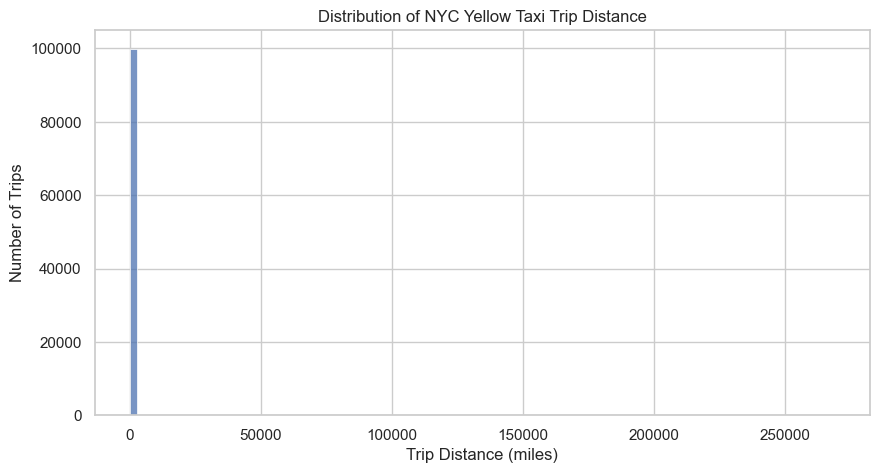

In [24]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=sample_for_plot,
    x="trip_distance",
    bins=100
)

plt.title("Distribution of NYC Yellow Taxi Trip Distance")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Number of Trips")

plt.show()

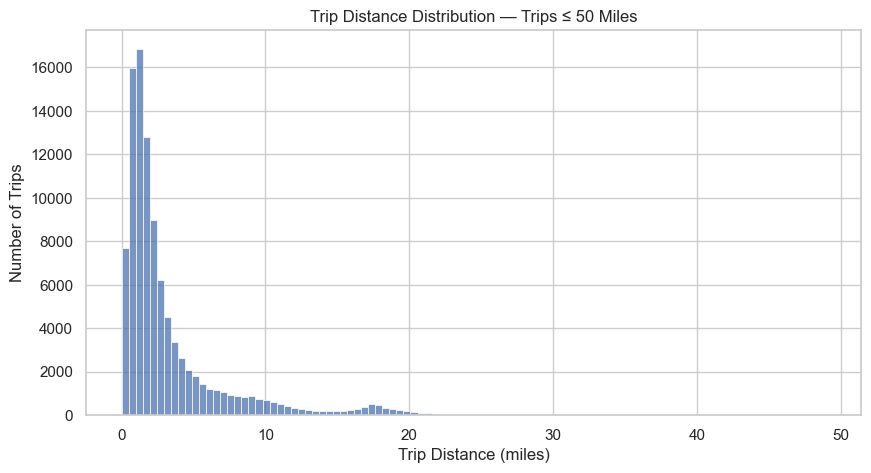

In [25]:
distance_plot = sample_for_plot[
    sample_for_plot["trip_distance"] <= 50
]

plt.figure(figsize=(10, 5))

sns.histplot(
    data=distance_plot,
    x="trip_distance",
    bins=100
)

plt.title("Trip Distance Distribution — Trips ≤ 50 Miles")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Number of Trips")

plt.show()

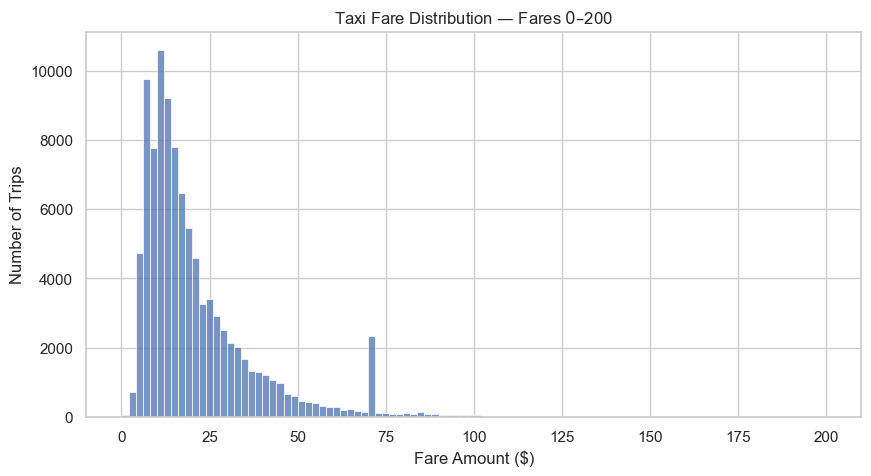

In [26]:
fare_plot = sample_for_plot[
    (sample_for_plot["fare_amount"] >= 0) &
    (sample_for_plot["fare_amount"] <= 200)
]

plt.figure(figsize=(10, 5))

sns.histplot(
    data=fare_plot,
    x="fare_amount",
    bins=100
)

plt.title("Taxi Fare Distribution — Fares $0–$200")
plt.xlabel("Fare Amount ($)")
plt.ylabel("Number of Trips")

plt.show()

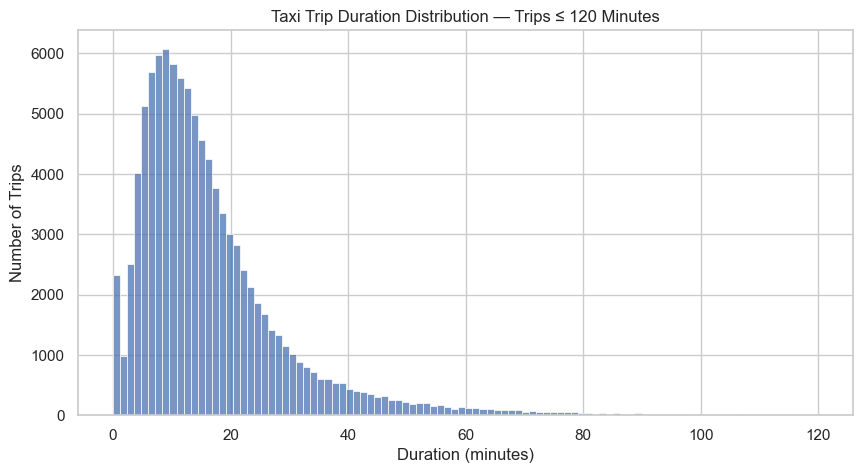

In [27]:
duration_plot = sample_for_plot[
    (sample_for_plot["duration_minutes"] >= 0) &
    (sample_for_plot["duration_minutes"] <= 120)
]

plt.figure(figsize=(10, 5))

sns.histplot(
    data=duration_plot,
    x="duration_minutes",
    bins=100
)

plt.title("Taxi Trip Duration Distribution — Trips ≤ 120 Minutes")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Trips")

plt.show()

## 6. Anomaly Investigation

The distributional analysis identified several unusual observations.

Rather than removing these observations solely because they are extreme, we investigate their associated attributes to determine whether they represent:

- legitimate but uncommon taxi trips,
- special fare structures,
- transactional adjustments,
- data-entry issues,
- or records that are unsuitable for modeling.

The investigation focuses on zero-distance trips, zero-duration trips, extreme distances, extreme durations, and negative fares.

In [28]:
zero_distance_analysis = duckdb.sql(f"""
SELECT
    COUNT(*) AS total_zero_distance,

    COUNT(*) FILTER (
        WHERE fare_amount = 0
    ) AS zero_fare,

    COUNT(*) FILTER (
        WHERE fare_amount > 0
    ) AS positive_fare,

    COUNT(*) FILTER (
        WHERE fare_amount < 0
    ) AS negative_fare,

    COUNT(*) FILTER (
        WHERE tpep_dropoff_datetime = tpep_pickup_datetime
    ) AS zero_duration,

    COUNT(*) FILTER (
        WHERE tpep_dropoff_datetime > tpep_pickup_datetime
    ) AS positive_duration,

    AVG(fare_amount) AS average_fare,
    AVG(total_amount) AS average_total

FROM '{files[0]}'
WHERE trip_distance = 0
""").df()

zero_distance_analysis.T

,0
total_zero_distance,125738.000000
zero_fare,501.000000
positive_fare,122482.000000
negative_fare,2755.000000
zero_duration,1164.000000
positive_duration,124574.000000
average_fare,27.965840
average_total,34.300725


In [29]:
zero_duration_analysis = duckdb.sql(f"""
SELECT
    COUNT(*) AS total_zero_duration,

    COUNT(*) FILTER (
        WHERE trip_distance = 0
    ) AS zero_distance,

    COUNT(*) FILTER (
        WHERE trip_distance > 0
    ) AS positive_distance,

    COUNT(*) FILTER (
        WHERE fare_amount = 0
    ) AS zero_fare,

    COUNT(*) FILTER (
        WHERE fare_amount > 0
    ) AS positive_fare,

    COUNT(*) FILTER (
        WHERE fare_amount < 0
    ) AS negative_fare,

    AVG(trip_distance) AS average_distance,
    AVG(fare_amount) AS average_fare

FROM '{files[0]}'
WHERE tpep_pickup_datetime = tpep_dropoff_datetime
""").df()

zero_duration_analysis.T

,0
total_zero_duration,45069.000000
zero_distance,1164.000000
positive_distance,43905.000000
zero_fare,15.000000
positive_fare,45054.000000
negative_fare,0.000000
average_distance,2.482444
average_fare,16.299239


In [30]:
extreme_distance_analysis = duckdb.sql(f"""
SELECT
    COUNT(*) AS trips,

    AVG(trip_distance) AS avg_distance,
    MIN(trip_distance) AS min_distance,
    MAX(trip_distance) AS max_distance,

    AVG(
        EXTRACT(
            EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)
        ) / 60
    ) AS avg_duration_minutes,

    AVG(fare_amount) AS avg_fare,

    COUNT(*) FILTER (
        WHERE fare_amount < 0
    ) AS negative_fares,

    COUNT(*) FILTER (
        WHERE trip_distance > 1000
    ) AS distance_over_1000

FROM '{files[0]}'
WHERE trip_distance > 100
""").df()

extreme_distance_analysis.T

,0
trips,162.000000
avg_distance,70893.201296
min_distance,100.370000
max_distance,269097.480000
avg_duration_minutes,52.663272
avg_fare,112.765494
negative_fares,6.000000
distance_over_1000,111.000000


In [31]:
extreme_duration_analysis = duckdb.sql(f"""
SELECT
    COUNT(*) AS trips,

    MIN(
        EXTRACT(
            EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)
        ) / 3600
    ) AS min_hours,

    MAX(
        EXTRACT(
            EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)
        ) / 3600
    ) AS max_hours,

    AVG(trip_distance) AS avg_distance,
    AVG(fare_amount) AS avg_fare,

    COUNT(*) FILTER (
        WHERE trip_distance = 0
    ) AS zero_distance,

    COUNT(*) FILTER (
        WHERE fare_amount < 0
    ) AS negative_fares

FROM '{files[0]}'
WHERE EXTRACT(
    EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)
) > 24 * 3600
""").df()

extreme_duration_analysis.T

,0
trips,35.000000
min_hours,24.053333
max_hours,125.131667
avg_distance,11.566571
avg_fare,29.832571
zero_distance,8.000000
negative_fares,1.000000


In [32]:
fare_around_70 = duckdb.sql(f"""
SELECT
    RatecodeID,
    COUNT(*) AS trips,
    AVG(trip_distance) AS avg_distance,
    AVG(fare_amount) AS avg_fare
FROM '{files[0]}'
WHERE fare_amount BETWEEN 65 AND 75
GROUP BY RatecodeID
ORDER BY trips DESC
""").df()

fare_around_70

,RatecodeID,trips,avg_distance,avg_fare
0,2,81118,17.390821,70.000268
1,1,10827,16.448267,69.426752
2,<NA>,10396,58.634077,69.350371
3,5,5258,5.549106,67.916476
4,99,1794,19.640635,68.914699
5,3,1130,11.770876,69.929204
6,4,422,14.040995,70.024171


### Investigating Fare Structure

The fare distribution shows a pronounced concentration around $70.

Rather than treating this as an outlier, we investigate whether the concentration is associated with specific taxi rate codes. This helps distinguish genuine fare structures from anomalous observations.

In [33]:
ratecode_analysis = duckdb.sql(f"""
SELECT
    RatecodeID,
    COUNT(*) AS trips,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(MIN(fare_amount), 2) AS min_fare,
    ROUND(MAX(fare_amount), 2) AS max_fare,
    ROUND(AVG(trip_distance), 2) AS avg_distance
FROM '{files[0]}'
GROUP BY RatecodeID
ORDER BY trips DESC
""").df()

ratecode_analysis

,RatecodeID,trips,avg_fare,min_fare,max_fare,avg_distance
0,1,2390495,15.37,-2555.20,2555.20,2.52
1,<NA>,1088058,25.38,-42.29,680.19,13.75
2,99,110864,35.44,0.00,2500.00,8.98
3,2,83592,65.96,-70.00,88.96,17.21
4,5,32030,67.50,-990.00,990.00,8.26
5,3,11541,61.18,-177.00,346.40,12.32
6,4,8304,98.48,-893.40,899.00,26.28
7,6,5,2.90,2.50,3.50,0.26


In [34]:
extreme_distance_records = duckdb.sql(f"""
SELECT
    tpep_pickup_datetime,
    tpep_dropoff_datetime,
    trip_distance,
    fare_amount,
    total_amount,
    passenger_count,
    PULocationID,
    DOLocationID,
    RatecodeID
FROM '{files[0]}'
WHERE trip_distance > 100
ORDER BY trip_distance DESC
LIMIT 20
""").df()

extreme_distance_records

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,total_amount,passenger_count,PULocationID,DOLocationID,RatecodeID
0,2026-01-28 01:08:00,2026-01-28 01:16:00,269097.48,12.19,16.94,<NA>,79,144,<NA>
1,2026-01-30 13:00:00,2026-01-30 13:38:00,237567.19,72.99,81.95,<NA>,42,130,<NA>
2,2026-01-21 16:31:00,2026-01-21 16:40:00,236216.69,13.58,21.33,<NA>,234,107,<NA>
3,2026-01-17 10:40:00,2026-01-17 10:57:00,236183.06,22.75,34.96,<NA>,137,82,<NA>
4,2026-01-02 21:31:00,2026-01-02 21:55:00,221544.91,31.21,39.55,<NA>,249,41,<NA>
5,2026-01-02 07:07:00,2026-01-02 07:18:00,221436.73,27.61,32.36,<NA>,231,161,<NA>
6,2026-01-17 10:39:00,2026-01-17 10:56:00,196490.48,33.59,38.34,<NA>,13,162,<NA>
7,2026-01-29 07:51:00,2026-01-29 08:26:00,192081.68,60.20,64.95,<NA>,33,246,<NA>
8,2026-01-07 17:51:00,2026-01-07 17:56:00,184908.33,12.18,16.93,<NA>,164,186,<NA>
9,2026-01-27 14:46:00,2026-01-27 16:10:00,183363.75,71.01,75.76,<NA>,230,74,<NA>


In [35]:
negative_fare_analysis = duckdb.sql(f"""
SELECT
    COUNT(*) AS negative_fare_trips,

    COUNT(*) FILTER (
        WHERE total_amount < 0
    ) AS negative_total_amount,

    COUNT(*) FILTER (
        WHERE trip_distance = 0
    ) AS zero_distance,

    COUNT(*) FILTER (
        WHERE trip_distance > 0
    ) AS positive_distance,

    COUNT(*) FILTER (
        WHERE RatecodeID IS NULL
    ) AS missing_ratecode,

    AVG(trip_distance) AS avg_distance,
    AVG(fare_amount) AS avg_fare,
    AVG(total_amount) AS avg_total

FROM '{files[0]}'
WHERE fare_amount < 0
""").df()

negative_fare_analysis.T

,0
negative_fare_trips,39463.000000
negative_total_amount,39445.000000
zero_distance,2755.000000
positive_distance,36708.000000
missing_ratecode,32.000000
avg_distance,4.082969
avg_fare,-24.554129
avg_total,-30.703067


In [36]:
negative_fare_records = duckdb.sql(f"""
SELECT
    tpep_pickup_datetime,
    tpep_dropoff_datetime,
    trip_distance,
    fare_amount,
    total_amount,
    RatecodeID,
    payment_type,
    extra,
    mta_tax,
    tip_amount,
    tolls_amount,
    improvement_surcharge,
    congestion_surcharge,
    airport_fee,
    cbd_congestion_fee
FROM '{files[0]}'
WHERE fare_amount < 0
ORDER BY fare_amount
LIMIT 20
""").df()

negative_fare_records

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,total_amount,RatecodeID,payment_type,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2026-01-25 00:43:10,2026-01-27 11:28:52,48.65,-2555.2,-2560.20,1,3,-1.00,-0.5,0.0,0.00,-1.0,-2.5,0.00,0.00
1,2026-01-19 17:09:00,2026-01-19 17:09:05,0.00,-990.0,-991.00,5,3,0.00,0.0,0.0,0.00,-1.0,0.0,0.00,0.00
2,2026-01-24 00:18:59,2026-01-24 00:43:52,9.03,-900.0,-904.25,5,4,0.00,0.0,0.0,0.00,-1.0,-2.5,0.00,-0.75
3,2026-01-26 13:30:11,2026-01-26 16:04:09,138.54,-893.4,-904.11,4,4,0.00,-0.5,0.0,-7.46,-1.0,0.0,-1.75,0.00
4,2026-01-19 13:10:40,2026-01-19 15:07:45,116.46,-826.2,-827.70,4,2,0.00,-0.5,0.0,0.00,-1.0,0.0,0.00,0.00
5,2026-01-29 20:16:15,2026-01-30 14:57:24,13.92,-800.3,-807.55,1,4,-2.50,-0.5,0.0,0.00,-1.0,-2.5,0.00,-0.75
6,2026-01-09 13:54:47,2026-01-09 13:54:55,0.03,-800.0,-801.00,5,3,0.00,0.0,0.0,0.00,-1.0,0.0,0.00,0.00
7,2026-01-26 22:08:33,2026-01-26 22:08:39,0.00,-748.0,-749.00,5,4,0.00,0.0,0.0,0.00,-1.0,0.0,0.00,0.00
8,2026-01-19 08:46:49,2026-01-19 10:59:12,142.92,-669.4,-670.40,4,2,0.00,0.0,0.0,0.00,-1.0,0.0,0.00,0.00
9,2026-01-31 20:35:07,2026-01-31 22:29:40,101.65,-630.9,-680.61,4,3,-1.00,0.0,0.0,-47.71,-1.0,0.0,0.00,0.00


In [37]:
duplicate_check = duckdb.sql(f"""
SELECT
    tpep_pickup_datetime,
    tpep_dropoff_datetime,
    trip_distance,
    fare_amount,
    PULocationID,
    DOLocationID,
    COUNT(*) AS occurrences
FROM '{files[0]}'
GROUP BY
    tpep_pickup_datetime,
    tpep_dropoff_datetime,
    trip_distance,
    fare_amount,
    PULocationID,
    DOLocationID
HAVING COUNT(*) > 1
ORDER BY occurrences DESC
LIMIT 20
""").df()

duplicate_check

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,PULocationID,DOLocationID,occurrences
0,2026-01-27 20:51:03,2026-01-27 21:52:05,10.01,0.0,68,60,2
1,2026-01-04 17:10:06,2026-01-04 17:14:12,1.18,0.0,48,68,2
2,2026-01-12 18:44:26,2026-01-12 18:52:15,0.00,0.0,236,236,2
3,2026-01-15 08:18:08,2026-01-15 08:18:25,0.00,0.0,107,107,2
4,2026-01-25 02:36:55,2026-01-25 02:49:21,1.02,0.0,79,79,2
5,2026-01-31 01:22:14,2026-01-31 01:29:04,0.52,0.0,148,148,2
6,2026-01-11 18:04:43,2026-01-11 18:20:10,1.38,0.0,48,48,2
7,2026-01-13 12:14:29,2026-01-13 12:14:57,0.00,0.0,68,68,2
8,2026-01-13 19:27:44,2026-01-13 19:52:39,0.35,0.0,229,229,2
9,2026-01-15 11:01:21,2026-01-15 11:02:05,0.00,0.0,234,234,2
